In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score
seed = 89189

def rel_mad(y_true, y_pred):
    """RelMAD: median absolute deviation of (E_pred - E_true) / E_true"""
    # y_true = np.exp(y_true_log)
    # y_pred = np.exp(y_pred_log)
    return np.median(np.abs((y_pred - y_true) / y_true))

from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
import umap
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'xgboost'

In [2]:
data_features = pd.read_csv(r"Supplementary_1\SuperCon_features.csv")
# data_features = pd.read_csv(r"C:\Users\Bruger\OneDrive - University of Copenhagen\Desktop\Uni\Applied Machine Learning\Final_project\Supplementary_1\Materials_Project_features.csv")

In [3]:
features = data_features.columns.to_list()
print(len(features))
np.savetxt("features.txt",features, fmt='%s')

147


In [4]:
T_c = np.load(r"Supplementary_1\SuperCon_critical_temperatures.npy")
print(len(T_c))

data = data_features
data["T_c"] = T_c.tolist()

13661


<Axes: >

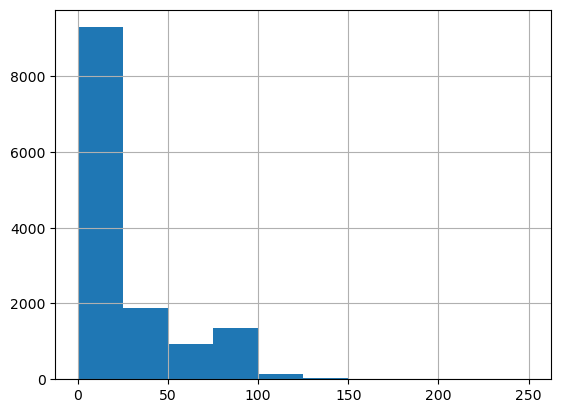

In [5]:
data["T_c"].hist()

In [6]:
X = data_features[features]
Y = data["T_c"]

X_train, x_test, Y_train, y_test = train_test_split(X,Y,test_size=0.15,random_state=seed+7476)

In [7]:
xgb_parms =  {'max_depth': 18, 'min_child_weight': 0.0073545199057444294, 'subsample': 0.6257244020866118, 'colsample_bytree': 0.6423093396565727, 'reg_alpha': 2.7228680167323867, 'learning_rate': 0.011299604822727892, 'gamma': 0.762624387769551, 'reg_lambda': 1.1686338108516046}


xgb_v1 = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    eval_metric="rmse",
    n_estimators=558,
    verbosity=0,
    seed=429,
    **xgb_parms
)

xgb_v1.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6423093396565727
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [8]:
y_pred_xgb = xgb_v1.predict(x_test)

relmad_xgb = rel_mad(np.array(y_test), y_pred_xgb)
r2_xgb     = r2_score(y_test, y_pred_xgb)

print(f"RelMAD: {relmad_xgb:.4f}  R²: {r2_xgb:.4f}")

RelMAD: 0.1530  R²: 0.9233


C:\Users\Bruger\AppData\Local\Temp\ipykernel_4260\1704281002.py:14: RuntimeWarning: divide by zero encountered in divide
  return np.median(np.abs((y_pred - y_true) / y_true))


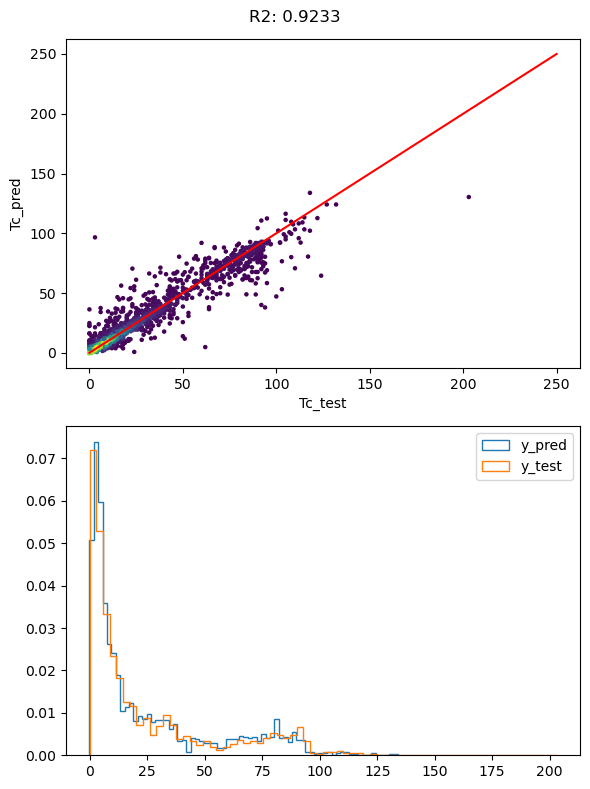

In [9]:
x_line = np.linspace(0, 250, 10)
x_line = np.linspace(0, 250, 10)
xy     = np.vstack([y_test, y_pred_xgb])
z      = gaussian_kde(xy)(xy)

fig, axs = plt.subplots(2, figsize=(6, 8))
axs[0].scatter(y_test, y_pred_xgb, c=z, s=5)
axs[0].plot(x_line, x_line, '-r')
axs[0].set_xlabel('Tc_test'); axs[0].set_ylabel('Tc_pred')
axs[1].hist(y_pred_xgb, alpha=1, histtype='step', density=True, bins=70, label='y_pred')
axs[1].hist(y_test, alpha=1, histtype='step', density=True, bins=70, label='y_test')
fig.suptitle(f"R2: {r2_xgb:.4f}")

axs[1].legend()
fig.tight_layout(); plt.show()

In [10]:
import shap
# Calculate SHAP values
explainer = shap.TreeExplainer(xgb_v1)
X_shap = X.sample(frac = 0.2,random_state = seed)
Y_shap = Y[X_shap.index]

In [ ]:
shap_values = explainer.shap_values(X_shap)

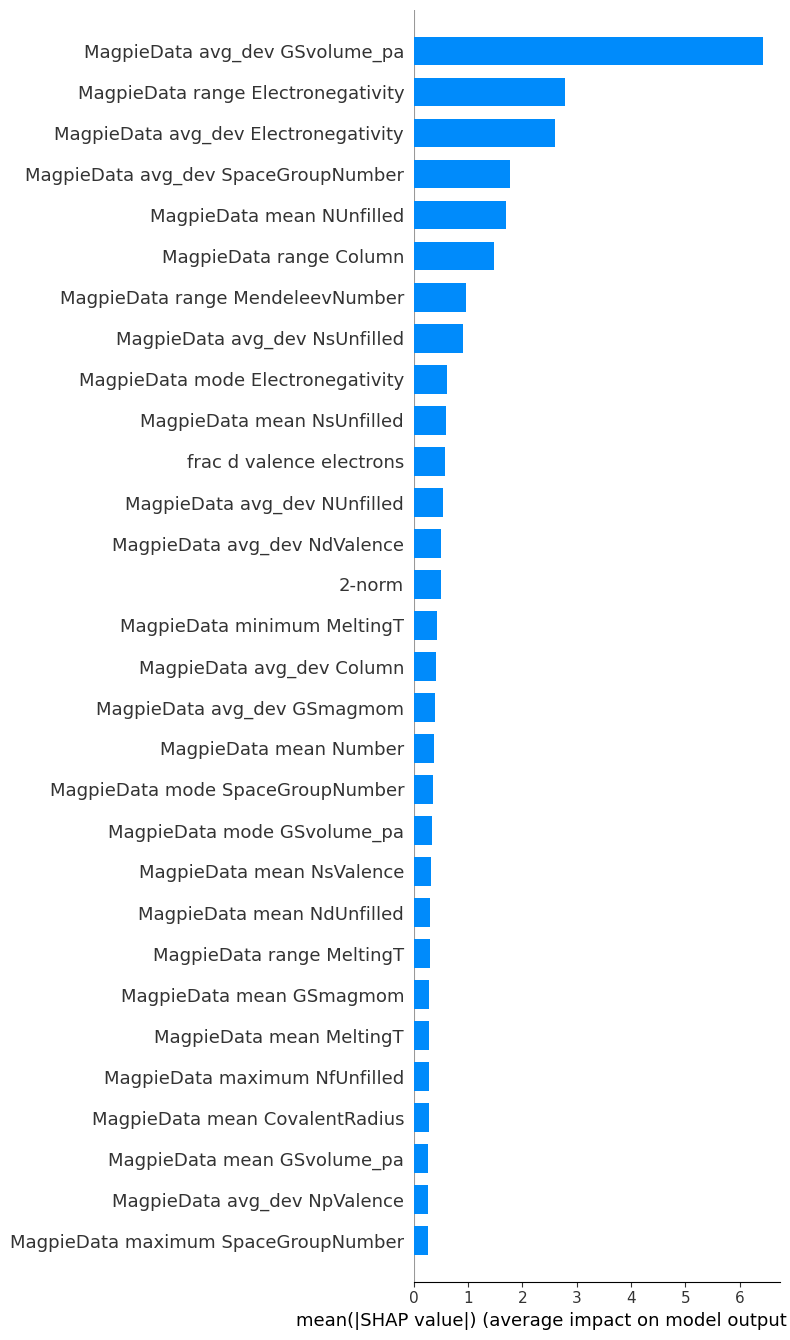

In [ ]:
fig = plt.figure(figsize=(4, 8))
shap.summary_plot(shap_values, X_shap, feature_names=features, 
                  plot_type="bar", max_display = 30)
plt.show()

### UMAP

In [11]:
qt = QuantileTransformer(n_quantiles=7000, output_distribution='normal', random_state=seed)
# X_norm = qt.fit_transform(X)
X_norm = pd.DataFrame(qt.fit_transform(X),columns=features)
X_norm.describe()

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,...,7-norm,10-norm,avg s valence electrons,avg p valence electrons,avg d valence electrons,avg f valence electrons,frac s valence electrons,frac p valence electrons,frac d valence electrons,frac f valence electrons
count,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,...,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000,13661.000000
mean,-0.042909,-0.002289,-0.047789,0.004174,-0.002036,0.020266,-0.040512,0.004082,-0.025907,-0.000472,...,-0.006110,-0.006355,1.289262,-0.484074,0.098619,-2.152560,-0.003552,-0.485455,-0.053770,-2.192472
std,1.166766,0.997614,1.163600,1.002571,1.001575,1.026463,1.153068,1.014714,1.092472,1.002496,...,1.009410,1.009458,2.723824,2.011429,1.587676,3.106781,1.001067,2.010273,1.196430,3.028528
min,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,...,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338
25%,-0.395040,-0.682718,-0.679331,-0.668096,-0.673462,-0.582935,-0.668992,-0.681362,-0.659837,-0.668109,...,-0.682266,-0.686428,-0.684075,-0.642790,-0.676852,-5.199338,-0.675736,-0.670661,-0.671896,-5.199338
50%,-0.395040,-0.017729,0.019341,0.005909,-0.002967,-0.022386,0.052850,0.400467,-0.000895,-0.005147,...,-0.003760,-0.001970,0.002328,-0.001617,0.006187,-0.009038,-0.005909,-0.003117,0.002806,-0.009412
75%,0.707572,0.716571,0.660282,0.681814,0.667458,0.683849,0.690879,0.400467,0.706422,0.669925,...,0.674153,0.674153,5.199338,0.677612,0.674377,0.673979,0.666603,0.672131,0.674778,0.675866
max,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,...,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338,5.199338


In [12]:
u_map = umap.UMAP(n_components=2, n_neighbors=10, random_state=42)#,min_dist = 0.1)
X_UMAP_fit = u_map.fit_transform(X_norm)

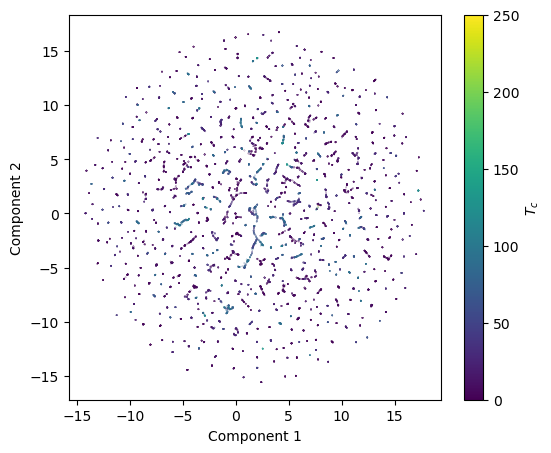

In [13]:
fig, ax = plt.subplots(1, figsize=(6, 5), dpi=100)
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')

sc = ax.scatter(X_UMAP_fit[:, 0], X_UMAP_fit[:, 1], s=0.02, c=Y)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$T_c$')  # optional label
# fig.savefig("umap_6feat.png")
plt.show()

In [14]:
from sklearn.manifold import TSNE
X_tsne_fit = TSNE(n_components=2, init='random', method='barnes_hut', 
            random_state=1837, perplexity=20, max_iter=500).fit_transform(X_norm)

tsneDf = pd.DataFrame(data = X_tsne_fit, columns = ['PC 1', 'PC 2'])

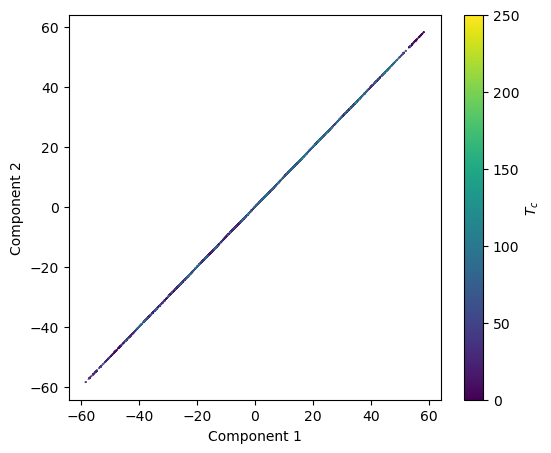

In [15]:
fig, ax = plt.subplots(1, figsize=(6, 5), dpi=100)
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')

sc = ax.scatter(tsneDf["PC 1"], tsneDf["PC 1"], s=0.02, c=Y)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$T_c$')  # optional label
# fig.savefig("umap_6feat.png")
plt.show()

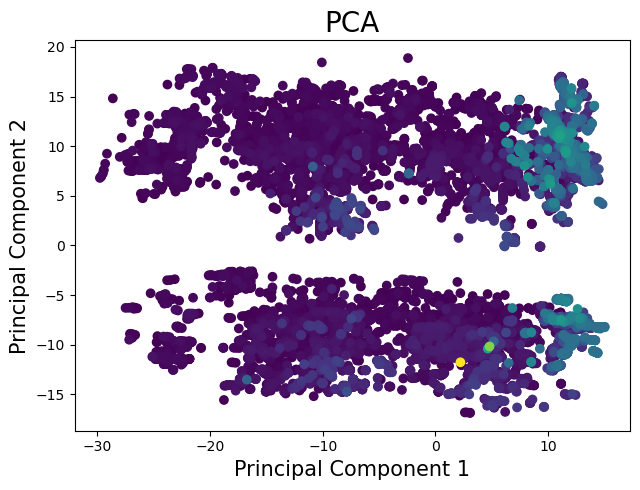

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# Run PCA.
pComp=pca.fit_transform(X_norm)
principalDf = pd.DataFrame(data = pComp, columns = ['PC 1', 'PC 2'])
fig = plt.figure(figsize = (6.5,5))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('PCA', fontsize = 20)
ax.scatter(principalDf.loc[:,'PC 1'],principalDf.loc[:,'PC 2'],c=Y)
fig.tight_layout()
plt.show()

In [17]:
from sklearn.decomposition import  KernelPCA

kpca = KernelPCA(n_components=2, kernel='cosine')
y_pcs = kpca.fit_transform(X_norm)

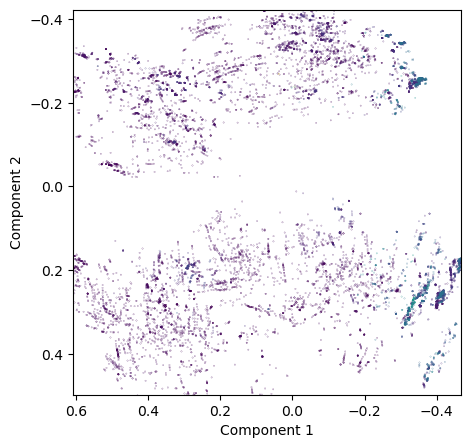

In [18]:
fig, ax = plt.subplots(1, figsize=(5, 5), dpi=100)
ax.set_xlim(np.percentile(y_pcs[:,0], 99), np.percentile(y_pcs[:,0], 1))
ax.set_ylim(np.percentile(y_pcs[:,1], 99), np.percentile(y_pcs[:,1], 1))
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')

ax.scatter(y_pcs[:,0], y_pcs[:,1], s=0.02, c=Y)
plt.show()

## MP

In [14]:
MP_features = pd.read_csv("../Supplementary_1/Materials_Project_features.csv")
MP_top_ids = np.load("Supplementary_1/Materials_Project_ambient_pressure_10_neighbors_top_candidates_ids.npy",  allow_pickle=True)
MP_top_Tc = np.load("Supplementary_1/Materials_Project_ambient_pressure_10_neighbors_top_candidates_critical_temperatures.npy",  allow_pickle=True)

#### Use same UMAP on the MP data. Plot together with predicted T_c

In [20]:
MP_features_norm = qt.transform(MP_features)
MP_features_umap = u_map.transform(MP_features_norm)

(array([1.02122e+05, 4.20440e+04, 6.45500e+03, 1.89400e+03, 4.82000e+02,
        1.67000e+02, 1.60000e+01, 6.00000e+00, 5.00000e+00, 1.80000e+01]),
 array([-1.46437213e-01,  2.04300652e+01,  4.10065651e+01,  6.15830688e+01,
         8.21595688e+01,  1.02736069e+02,  1.23312576e+02,  1.43889069e+02,
         1.64465576e+02,  1.85042084e+02,  2.05618576e+02]),
 <BarContainer object of 10 artists>)

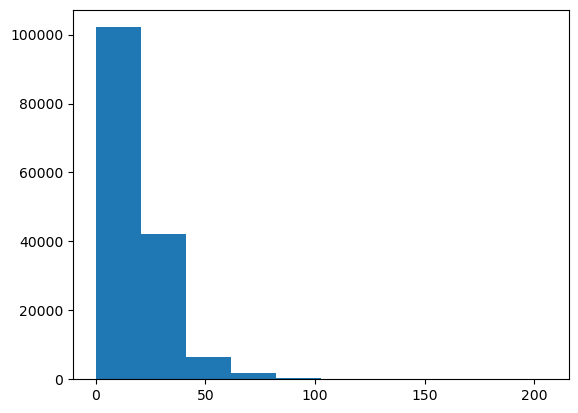

In [21]:
Tc_MP_pred = xgb_v1.predict(MP_features)
plt.hist(Tc_MP_pred)

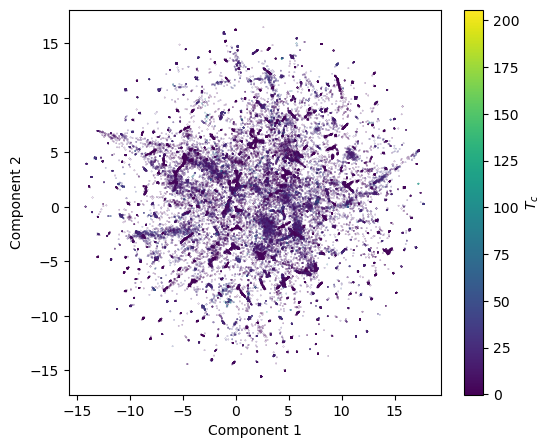

In [22]:
fig, ax = plt.subplots(1, figsize=(6, 5), dpi=100)
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')

sc = ax.scatter(MP_features_umap[:, 0], MP_features_umap[:, 1], s=0.02, c=Tc_MP_pred)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$T_c$')  # optional label
# fig.savefig("umap_6feat.png")
plt.show()

In [23]:
print(max(Tc_MP_pred))

205.61858


In [24]:
print(np.shape(MP_top_ids),np.shape(MP_top_Tc))

(41559,) (41559,)


In [25]:
print(MP_top_ids[0],MP_top_Tc[0])

mp-765341 316.46404404943974


In [26]:
print(MP_top_ids)

['mp-765341' 'mp-753273' 'mp-753257' ... 'mp-569913' 'mp-1080448'
 'mp-1226749']


In [15]:
qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=seed)
X_train_scaled = pd.DataFrame(qt.fit_transform(X_train), columns=X_train.columns)
x_test_scaled  = pd.DataFrame(qt.transform(x_test), columns=x_test.columns)
MP_features_scaled = pd.DataFrame(qt.transform(MP_features), columns=MP_features.columns)

X_scaled = pd.DataFrame(qt.transform(X), columns=X.columns)

X_train_scaled = X_train_scaled.reset_index(drop=True)
Y_train_reindex = Y_train.reset_index(drop=True,inplace=False)
X_test_scaled  = x_test_scaled.reset_index(drop=True)
Y_test_reindex  = y_test.reset_index(drop=True,inplace=False)
MP_features_scaled = MP_features_scaled.reset_index(drop=True)

In [16]:
# Fra artikel
from sklearn.linear_model import RidgeCV, Ridge 
from sklearn.neighbors import KNeighborsRegressor 

def ridge_regression_prediction_and_coefficients(train_features, train_labels, test_features):
    alphas_range = np.linspace(0.01, 50, 500)
    ridgecv = RidgeCV(alphas = alphas_range)
    ridgecv.fit(np.array(train_features), train_labels)
    alpha = ridgecv.alpha_ 

    ridge = Ridge(alpha = alpha, solver = "cholesky")
    ridge.fit(np.array(train_features), train_labels)
    ridge_prediction = ridge.predict(np.array(test_features))[0]
    ridge_prediction = np.abs(ridge_prediction)
    ridge_coefficients = ridge.coef_ 

    return ridge_prediction, ridge_coefficients 

def similarity_based_ridge_regression(train_features, train_labels, test_features, n_neighbors):
    knn_regressor = KNeighborsRegressor(n_neighbors = n_neighbors, n_jobs = -1)
    knn_regressor.fit(train_features, train_labels)
    knn_indices = knn_regressor.kneighbors(test_features)[1][0]
    test_prediction, ridge_coefficients = ridge_regression_prediction_and_coefficients(
        train_features.iloc[knn_indices], 
        train_labels.iloc[knn_indices], 
        test_features
    )
    
    return test_prediction, ridge_coefficients

In [64]:
all_predictions = []

for i in range(len(x_test_scaled)):
    pred, _ = similarity_based_ridge_regression(
        X_train_scaled, 
        Y_train_reindex, 
        x_test_scaled.iloc[[i]],  # single row, double brackets to keep DataFrame shape
        n_neighbors=10
    )
    all_predictions.append(pred)
    if i%100==0:
        print(i," done")

test_predictions = np.array(all_predictions)

0  done
100  done
200  done
300  done
400  done
500  done
600  done
700  done
800  done
900  done
1000  done
1100  done
1200  done
1300  done
1400  done
1500  done
1600  done
1700  done
1800  done
1900  done
2000  done


In [65]:
r2_ridge = r2_score(Y_test_reindex, test_predictions)

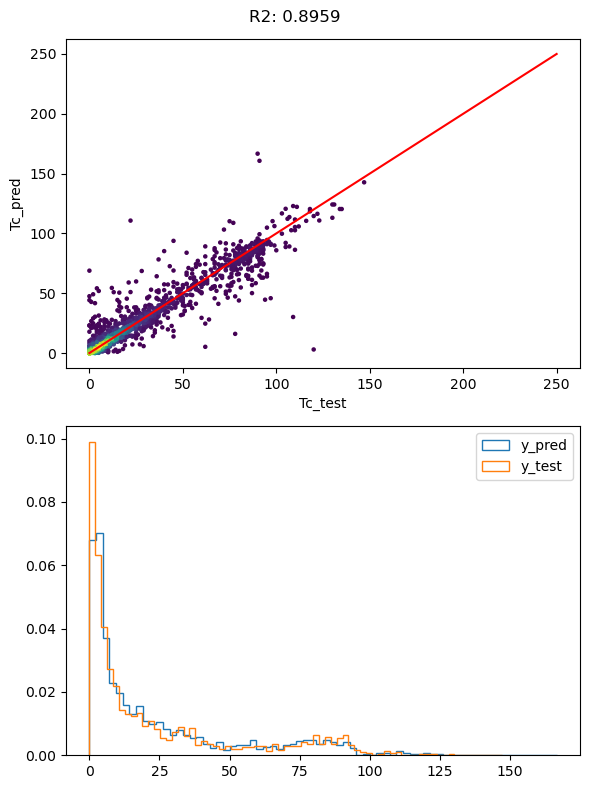

In [66]:
x_line = np.linspace(0, 250, 10)
x_line = np.linspace(0, 250, 10)
xy     = np.vstack([y_test, test_predictions])
z      = gaussian_kde(xy)(xy)

fig, axs = plt.subplots(2, figsize=(6, 8))
axs[0].scatter(y_test, test_predictions, c=z, s=5)
axs[0].plot(x_line, x_line, '-r')
axs[0].set_xlabel('Tc_test'); axs[0].set_ylabel('Tc_pred')
axs[1].hist(test_predictions, alpha=1, histtype='step', density=True, bins=70, label='y_pred')
axs[1].hist(y_test, alpha=1, histtype='step', density=True, bins=70, label='y_test')
fig.suptitle(f"R2: {r2_ridge:.4f}")

axs[1].legend()
fig.tight_layout(); plt.show()

In [45]:
print(np.max(test_prediction))

95.85024234260385


In [46]:
MP_predictios,_ = similarity_based_ridge_regression(X_train,Y_train,MP_features,10)

In [17]:
from tqdm import tqdm
all_predictions = []
MP_features_scaled_sample = MP_features_scaled.sample(n=50_000,random_state=1001)
MP_features_scaled_sample = MP_features_scaled
indecies = MP_features_scaled_sample.index

for i in tqdm(range(len(MP_features_scaled_sample))):
    pred, _ = similarity_based_ridge_regression(
        X_scaled, 
        Y, 
        MP_features_scaled_sample.iloc[[i]],  # single row, double brackets to keep DataFrame shape
        n_neighbors=10
    )
    all_predictions.append(pred)
    # if i%100==0:
    #     print(i," done")

MP_predictions = np.array(all_predictions)

100%|██████████| 153209/153209 [5:19:37<00:00,  7.99it/s]  


In [21]:
MP_pred_data = np.vstack((indecies,MP_predictions)).T

In [ ]:
np.savetxt("MP_pred.csv",MP_pred_data,fmt=['%d', '%.6f'],delimiter=',')


In [9]:
MP_predictions = np.genfromtxt("MP_pred.csv",delimiter = ',')
MP_predictions = MP_predictions[:,1]

In [10]:
MP_predictions

array([17.525203, 18.346753, 22.910634, ...,  6.050948,  6.050948,
        6.050948])

946.163289


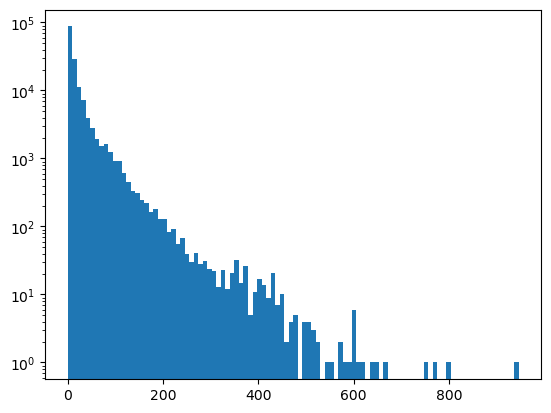

In [12]:
plt.hist(MP_predictions,bins=100)
plt.yscale('log')
print(max(MP_predictions))